In [1]:

import os
import getpass
import json
import altair as alt

import pandas as pd
from sklearn.manifold import TSNE
import umap
import numpy as np
from ast import literal_eval
# create interactive plot with gradio
import gradio as gr
from gradio.components import scatter_plot
import requests
from itertools import islice
import hdbscan
from sklearn import metrics
import matplotlib.pyplot as plt
import seaborn as sns
reducer = umap.UMAP()
from sklearn.cluster import KMeans
alt.data_transformers.disable_max_rows()


/home/chris/Data/Projects/py_venv/nanopy310/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DataTransformerRegistry.enable('default')

In [2]:

# load the embeddings from the json files
folder_path = 'embeddings'
json_files = [f for f in os.listdir(folder_path) if f.endswith('.json')]
# json_files = json_files[:1000]
data = {}

for file in json_files:
    with open(os.path.join(folder_path, file), 'r') as f:
        data[file] = json.load(f)

# data to dataframe
df = pd.DataFrame(data).T
df['size'] = 10
df['color'] = 'red'

# replace abstracts with the first abstract in the list if it is a list
df['abstract'] = df['abstract'].apply(lambda x: x[0] if isinstance(x, list) else x)

# filter the dataframe to only include journals from the following list
# List of journals to include
journals_to_include = [
    "ACS Applied Materials & Interfaces",
    "ACS Nano",
    "Advanced Functional Materials",
    "Advanced Materials",
    "Angewandte Chemie",
    "Biology and Medicine",
    "Biomaterials",
    "Cell",
    "Clinical Cancer Research",
    "Frontiers in Nanotechnology",
    "Immunity",
    "International Journal of Nanomedicine",
    "Journal of Controlled Release",
    "Journal of Materials Chemistry B",
    "Matter",
    "Molecular Therapy",
    "Nano Letters",
    "Nano Micro Small",
    "Nano Research",
    "Nanomedicine",
    "Nanomedicine: Nanotechnology",
    "Nanoscale",
    "Nature",
    "Nature Biomedical Engineering",
    "Nature Cancer",
    "Nature Communications",
    "Nature Materials",
    "Nature Medicine",
    "Nature Nanotechnology",
    "NPG Asia Materials",
    "Pharmaceutics",
    "PNAS",
    "Science",
    "Science Advances",
    "Science Translational Medicine",
    "Scientific Reports",
    "Small"
]

# journals as small letters
journals_to_include = [journal.lower() for journal in journals_to_include]

# Exclusion criteria
keywords_exclusion = ["review", "not available"]

# filter the dataframe to only include journals from the list
df = df[df['journal'].str.lower().isin(journals_to_include)]

# filter the dataframe to exclude titles with keywords from the exclusion list
df = df[~df['title'].str.lower().str.contains('|'.join(keywords_exclusion))]

# store the embeddings in a numpy array
embeddings = np.array(df['embedding'].map(lambda x: np.array(x)))
embeddings = np.stack(embeddings)


In [4]:
# create a t-SNE object
tsne = TSNE(n_components=2, random_state=42, init='random', learning_rate=200, max_iter=1000)

# fit the t-SNE object to the embeddings
tsne_embeddings = tsne.fit_transform(np.stack(embeddings[:]))

# create new pandas df with old df added the tsne embeddings
df_tsne = df.copy()

df_tsne['tsne_x'] = tsne_embeddings[:, 0]
df_tsne['tsne_y'] = tsne_embeddings[:, 1]



In [5]:
# write df_tsne to a csv file
df_tsne.to_csv('df_tsne.csv', index=False)

In [40]:
clusterer = hdbscan.HDBSCAN(min_cluster_size=100,  prediction_data=True, branch_detection_data=True, alpha=0.5, cluster_selection_method='leaf').fit(tsne_embeddings)

In [41]:
# number of clusters
n_clusters_ = len(set(clusterer.labels_)) - (1 if -1 in clusterer.labels_ else 0)

In [42]:
n_clusters_

15

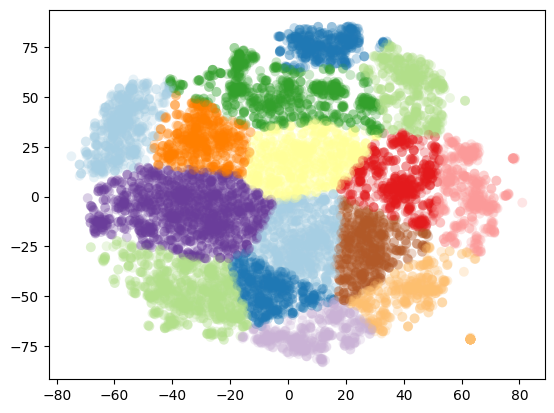

In [43]:
soft_clusters = hdbscan.all_points_membership_vectors(clusterer)
color_palette = sns.color_palette('Paired', n_clusters_)
cluster_colors = [color_palette[np.argmax(x)]
                  for x in soft_clusters]
plt.scatter(*tsne_embeddings.T, s=50, linewidth=0, c=cluster_colors, alpha=0.25)

In [44]:
cluster_colors

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (1.0, 1.0, 0.6),
 (1.0, 1.0, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (1.0, 0.4980392156862745, 0.0),
 (1.0, 0.4980392156862745, 0.0),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 0.4980392156862745, 0.0),
 (0.41568627450980394, 0.23921

In [38]:
len(color_palette)

12

In [6]:
# run kmeans on the tsne embeddings
kmeans = KMeans(n_clusters=10, random_state=0).fit(tsne_embeddings)
kmeans_labels = kmeans.labels_


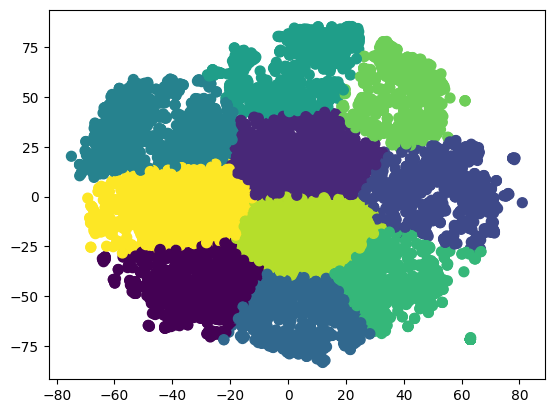

In [7]:
# plot the kmeans clusters
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=kmeans_labels, s=50, cmap='viridis')

In [8]:
kmeans_labels

array([4, 1, 1, ..., 5, 4, 3], dtype=int32)

In [9]:
# change the color palette to a list
color_palette = sns.color_palette('Paired', 10)

In [12]:
color_palette

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509)]

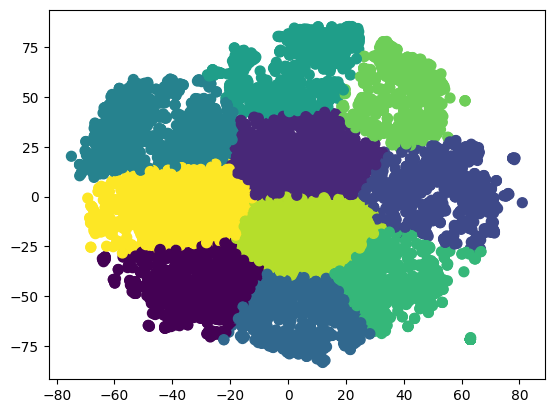

In [13]:
# plot with new color palette
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=

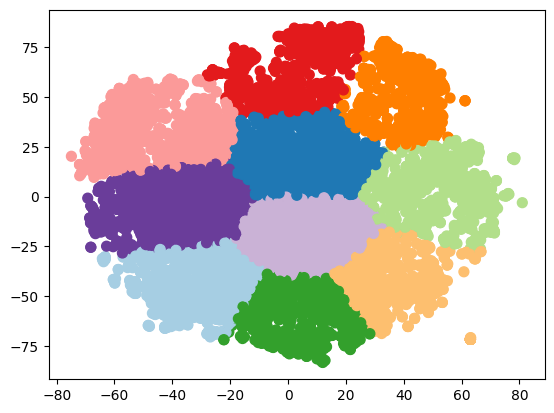

In [14]:
# use kmeans_labels to get the color from the color palette
plt.scatter(tsne_embeddings[:, 0], tsne_embeddings[:, 1], c=[color_palette[x] for x in kmeans_labels], s=50)